In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap
from module_new import FlowMatchingModel
import random
import seaborn as sns
from sklearn.manifold import TSNE
import scienceplots
plt.style.use('science')

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

class ResNetEmbeddingExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=self.device)
        self.model.to(self.device).eval()

    def extract_embeddings(self, input_maps, batch_size=32):
        """
        input_maps: (N, 4, H, W) stacked [star, gas, T, P]
        """
        all_embeddings = []
        for i in tqdm(range(0, len(input_maps), batch_size), desc="Extracting embeddings"):
            batch = torch.tensor(input_maps[i:i+batch_size], dtype=torch.float32, device=self.device)
            with torch.no_grad():
                emb = self.model.resnet_branch(batch)
            all_embeddings.append(emb.cpu().numpy())
            del batch
            torch.cuda.empty_cache()
        return np.vstack(all_embeddings)

    def sample_from_embedding(self, embedding, cdm_mass_map, astro_params, num_steps=50):
        """
        Generate maps from a given embedding vector and conditioning inputs.
        """
        cdm_mass_tensor = torch.tensor(cdm_mass_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(self.device)
        astro_params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(self.device)
        embedding_tensor = torch.tensor(embedding, dtype=torch.float32).unsqueeze(0).to(self.device)

        with torch.no_grad():
            pred = self.model.sample(
                cdm_mass=cdm_mass_tensor,
                astro_params=astro_params_tensor,
                cdm_mass_condition=cdm_mass_tensor,
                resnet_input=None,
                resnet_embed=embedding_tensor,
                num_steps=num_steps,
                method='euler'
            ).cpu().numpy()[0]
        return pred


def normalize_map(m):
    """Log1p + z-score normalization."""
    m_log = np.log1p(m)
    return (m_log - m_log.mean()) / m_log.std()


def prepare_resnet_input(star_map, gas_map, T_map, P_map):
    """Prepare stacked 4-channel ResNet input."""
    return np.stack([
        normalize_map(star_map),
        normalize_map(gas_map),
        normalize_map(T_map),
        normalize_map(P_map)
    ], axis=0)


def interpolate_embeddings(emb1, emb2, num_points=5):
    """Linear interpolation between two embeddings."""
    alphas = np.linspace(0, 1, num_points)
    return [(1-a)*emb1 + a*emb2 for a in alphas]


# ===== Usage Example =====

# Load your data
star_maps = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_Mstar_Astrid_LH_z=0.00.npy')
gas_maps  = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_Mgas_Astrid_LH_z=0.00.npy')
T_maps    = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_T_Astrid_LH_z=0.00.npy')
P_maps    = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_P_Astrid_LH_z=0.00.npy')
cdm_maps  = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_Mcdm_Astrid_LH_z=0.00.npy')
astro_params_all = np.loadtxt('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/params_LH_Astrid.txt')

# Pick N samples to extract embeddings
N = 5000
input_maps = np.array([
    prepare_resnet_input(star_maps[i], gas_maps[i], T_maps[i], P_maps[i])
    for i in np.random.choice(len(star_maps), N, replace=False)
])

# Extract embeddings
extractor = ResNetEmbeddingExtractor('lightning_logs/new/checkpoints/best-model-epoch=92-val_loss=0.035356.ckpt')
embeddings = extractor.extract_embeddings(input_maps)

# Pick two samples and interpolate
idx_a, idx_b = 0, 5
embeddings_interp = interpolate_embeddings(embeddings[idx_a], embeddings[idx_b], num_points=7)

# Decode interpolated embeddings
decoded_maps = [
    extractor.sample_from_embedding(
        emb, 
        normalize_map(cdm_maps[idx_a]),  # use same CDM mass map for conditioning
        astro_params_all[idx_a//15,:2],
        num_steps=200
    )
    for emb in embeddings_interp
]


In [2]:
class ResNetEmbeddingExtractor:
    """
    Alternative extractor that directly extracts ResNet embeddings without 
    needing to run the full UNet forward pass
    """
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
    def extract_embeddings(self, total_mass, star_maps, gas_maps, T_maps, P_maps, astro_params, batch_size=25):
        """
        Directly extract ResNet embeddings without running the full model
        """
        all_embeddings = []
        n_samples = len(total_mass)
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            # Prepare target maps tensor
            target_maps = torch.stack([
                torch.FloatTensor(star_maps[i:end_idx]),
                torch.FloatTensor(gas_maps[i:end_idx]),
                torch.FloatTensor(T_maps[i:end_idx]),
                torch.FloatTensor(P_maps[i:end_idx])
            ], dim=1).to(self.device)
            
            with torch.no_grad():
                # Directly compute ResNet embeddings
                embeddings = self.model.resnet_branch(target_maps)
                all_embeddings.append(embeddings.detach().cpu().numpy())
            
            # Clear memory
            del target_maps
            torch.cuda.empty_cache()
        
        return np.vstack(all_embeddings) if all_embeddings else np.array([])
    
    def extract_custom_embeddings(self, custom_input, batch_size=25):
        """
        Extract embeddings from custom input tensors
        """
        all_embeddings = []
        n_samples = custom_input.shape[0]
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            input_batch = torch.FloatTensor(custom_input[i:end_idx]).to(self.device)
            
            with torch.no_grad():
                embeddings = self.model.resnet_branch(input_batch)
                all_embeddings.append(embeddings.detach().cpu().numpy())
            
            del input_batch
            torch.cuda.empty_cache()
        
        return np.vstack(all_embeddings) if all_embeddings else np.array([])

# Even simpler version that just returns predictions vs truth
def sampling(checkpoint_path, idx_sim,
             cdm_mass_path_sim, star_maps_path_sim, gas_maps_path_sim, 
             T_maps_path_sim, P_maps_path_sim, params_path_sim,
             num_steps=50):

    # Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
    model.to(device)
    model.eval()

    # Load data
    cdm_mass_maps = np.load(cdm_mass_path_sim)
    star_maps = np.load(star_maps_path_sim)
    gas_maps = np.load(gas_maps_path_sim)
    T_maps = np.load(T_maps_path_sim)
    P_maps = np.load(P_maps_path_sim)
    params = np.loadtxt(params_path_sim)

    # Normalize
    sample_tot = np.log1p(cdm_mass_maps[idx_sim])
    tot_mean, tot_std = np.log1p(cdm_mass_maps).mean(), np.log1p(cdm_mass_maps).std()
    sample_tot_norm = (sample_tot - tot_mean) / tot_std
    
    # Add noise
    noisy_tot = sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
    
    # Truth maps
    star_map_norm = (np.log1p(star_maps[idx_sim]) - np.log1p(star_maps[idx_sim]).mean()) / np.log1p(star_maps[idx_sim]).std()
    gas_map_norm = (np.log1p(gas_maps[idx_sim]) - np.log1p(gas_maps[idx_sim]).mean()) / np.log1p(gas_maps[idx_sim]).std()
    T_map_norm = (np.log1p(T_maps[idx_sim]) - np.log1p(T_maps[idx_sim]).mean()) / np.log1p(T_maps[idx_sim]).std()
    P_map_norm = (np.log1p(P_maps[idx_sim]) - np.log1p(P_maps[idx_sim]).mean()) / np.log1p(P_maps[idx_sim]).std()
    
    # ResNet input
    truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm, P_map_norm], axis=0)
    resnet_input_tensor = torch.tensor(truth_maps, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Prepare tensors
    cdm_mass_tensor = torch.tensor(noisy_tot, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    cond_tensor = torch.tensor(sample_tot_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    astro_params = params[idx_sim//15, :2]
    params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Generate prediction
    with torch.no_grad():
        pred = model.sample(
            cdm_mass=cdm_mass_tensor,
            astro_params=params_tensor,
            cdm_mass_condition=cond_tensor,
            resnet_input=resnet_input_tensor,
            resnet_embed=None,
            num_steps=num_steps,
            method='euler'
        ).cpu().numpy()[0]
    
    return {
        'prediction': pred,  # Shape: (4, 256, 256)
        'truth': {
            'star': star_map_norm,
            'gas': gas_map_norm,
            'T': T_map_norm,
            'P': P_map_norm
        },
        'input': {
            'cdm_mass': noisy_tot,
            'astro_params': astro_params
        }
    }

checkpoint_path = 'lightning_logs/new/checkpoints/best-model-epoch=92-val_loss=0.035356.ckpt'
simulation_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid', 'Magneticum']

print("Extracting ResNet features...")
extractor = ResNetEmbeddingExtractor(checkpoint_path)

all_features_resnet = []
all_labels_resnet = []
all_cosmo_params = []
all_astro_params = []

for model_name in simulation_models:
    print(f"Processing {model_name}...")
    total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = load_model_data(model_name, 
                                                                                                  n_samples=5000)
    features = extractor.extract_embeddings(total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params)
    
    if len(features) > 0:
        all_features_resnet.append(features)
        all_labels_resnet.extend([model_name] * len(features))
        all_cosmo_params.append(cosmo_params)
        all_astro_params.append(astro_params)

# UMAP
X_resnet_indv = np.vstack(all_features_resnet)
print(f"Total features: {X_resnet_indv.shape}")

output = sampling(
    checkpoint_path='/n/netscratch/iaifi_lab/Lab/msliu/FM_4channel/lightning_logs/simba_only/checkpoints/best-model-epoch=156-val_loss=0.029530.ckpt',
    idx_sim=10,
    # SIMBA dataset paths
    cdm_mass_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mcdm_SIMBA_CV_z=0.00.npy',
    star_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mstar_SIMBA_CV_z=0.00.npy',
    gas_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mgas_SIMBA_CV_z=0.00.npy',
    T_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_T_SIMBA_CV_z=0.00.npy',
    P_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_P_SIMBA_CV_z=0.00.npy',
    params_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/params_CV_SIMBA.txt',
    num_steps=1000
)

In [ ]:
# Even simpler version that just returns predictions vs truth
def sampling(checkpoint_path, idx_sim,
             cdm_mass_path_sim, star_maps_path_sim, gas_maps_path_sim, 
             T_maps_path_sim, P_maps_path_sim, params_path_sim,
             num_steps=50):

    # Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
    model.to(device)
    model.eval()

    # Load data
    cdm_mass_maps = np.load(cdm_mass_path_sim)
    star_maps = np.load(star_maps_path_sim)
    gas_maps = np.load(gas_maps_path_sim)
    T_maps = np.load(T_maps_path_sim)
    P_maps = np.load(P_maps_path_sim)
    params = np.loadtxt(params_path_sim)

    # Normalize
    sample_tot = np.log1p(cdm_mass_maps[idx_sim])
    tot_mean, tot_std = np.log1p(cdm_mass_maps).mean(), np.log1p(cdm_mass_maps).std()
    sample_tot_norm = (sample_tot - tot_mean) / tot_std
    
    # Add noise
    noisy_tot = sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
    
    # Truth maps
    star_map_norm = (np.log1p(star_maps[idx_sim]) - np.log1p(star_maps[idx_sim]).mean()) / np.log1p(star_maps[idx_sim]).std()
    gas_map_norm = (np.log1p(gas_maps[idx_sim]) - np.log1p(gas_maps[idx_sim]).mean()) / np.log1p(gas_maps[idx_sim]).std()
    T_map_norm = (np.log1p(T_maps[idx_sim]) - np.log1p(T_maps[idx_sim]).mean()) / np.log1p(T_maps[idx_sim]).std()
    P_map_norm = (np.log1p(P_maps[idx_sim]) - np.log1p(P_maps[idx_sim]).mean()) / np.log1p(P_maps[idx_sim]).std()
    
    # ResNet input
    truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm, P_map_norm], axis=0)
    resnet_input_tensor = torch.tensor(truth_maps, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Prepare tensors
    cdm_mass_tensor = torch.tensor(noisy_tot, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    cond_tensor = torch.tensor(sample_tot_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    astro_params = params[idx_sim//15, :2]
    params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Generate prediction
    with torch.no_grad():
        pred = model.sample(
            cdm_mass=cdm_mass_tensor,
            astro_params=params_tensor,
            cdm_mass_condition=cond_tensor,
            resnet_input=resnet_input_tensor,
            resnet_embed=None,
            num_steps=num_steps,
            method='euler'
        ).cpu().numpy()[0]
    
    return {
        'prediction': pred,  # Shape: (4, 256, 256)
        'truth': {
            'star': star_map_norm,
            'gas': gas_map_norm,
            'T': T_map_norm,
            'P': P_map_norm
        },
        'input': {
            'cdm_mass': noisy_tot,
            'astro_params': astro_params
        }
    }

In [ ]:
checkpoint_path = 'lightning_logs/new/checkpoints/best-model-epoch=92-val_loss=0.035356.ckpt'
simulation_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid', 'Magneticum']

print("Extracting ResNet features...")
extractor = ResNetEmbeddingExtractor(checkpoint_path)

all_features_resnet = []
all_labels_resnet = []
all_cosmo_params = []
all_astro_params = []

for model_name in simulation_models:
    print(f"Processing {model_name}...")
    total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = load_model_data(model_name, 
                                                                                                  n_samples=5000)
    features = extractor.extract_embeddings(total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params)
    
    if len(features) > 0:
        all_features_resnet.append(features)
        all_labels_resnet.extend([model_name] * len(features))
        all_cosmo_params.append(cosmo_params)
        all_astro_params.append(astro_params)

# UMAP
X_resnet_indv = np.vstack(all_features_resnet)
print(f"Total features: {X_resnet_indv.shape}")

In [ ]:
output = sampling(
    checkpoint_path='/n/netscratch/iaifi_lab/Lab/msliu/FM_4channel/lightning_logs/simba_only/checkpoints/best-model-epoch=156-val_loss=0.029530.ckpt',
    idx_sim=10,
    # SIMBA dataset paths
    cdm_mass_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mcdm_SIMBA_CV_z=0.00.npy',
    star_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mstar_SIMBA_CV_z=0.00.npy',
    gas_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mgas_SIMBA_CV_z=0.00.npy',
    T_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_T_SIMBA_CV_z=0.00.npy',
    P_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_P_SIMBA_CV_z=0.00.npy',
    params_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/params_CV_SIMBA.txt',
    num_steps=1000
)

In [8]:
import torch
import numpy as np
from tqdm import tqdm

class ResNetEmbeddingExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=self.device)
        self.model.to(self.device).eval()

    def extract_embeddings(self, input_maps, batch_size=32):
        """
        input_maps: (N, 4, H, W) stacked [star, gas, T, P]
        """
        all_embeddings = []
        for i in tqdm(range(0, len(input_maps), batch_size), desc="Extracting embeddings"):
            batch = torch.tensor(input_maps[i:i+batch_size], dtype=torch.float32, device=self.device)
            with torch.no_grad():
                emb = self.model.resnet_branch(batch)
            all_embeddings.append(emb.cpu().numpy())
            del batch
            torch.cuda.empty_cache()
        return np.vstack(all_embeddings)

    def sample_from_embedding(self, embedding, cdm_mass_map, astro_params, num_steps=50):
        """
        Generate maps from a given embedding vector and conditioning inputs.
        """
        cdm_mass_tensor = torch.tensor(cdm_mass_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(self.device)
        astro_params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(self.device)
        embedding_tensor = torch.tensor(embedding, dtype=torch.float32).unsqueeze(0).to(self.device)

        with torch.no_grad():
            pred = self.model.sample(
                cdm_mass=cdm_mass_tensor,
                astro_params=astro_params_tensor,
                cdm_mass_condition=cdm_mass_tensor,
                resnet_input=None,
                resnet_embed=embedding_tensor,
                num_steps=num_steps,
                method='euler'
            ).cpu().numpy()[0]
        return pred


def normalize_map(m):
    """Log1p + z-score normalization."""
    m_log = np.log1p(m)
    return (m_log - m_log.mean()) / m_log.std()


def prepare_resnet_input(star_map, gas_map, T_map, P_map):
    """Prepare stacked 4-channel ResNet input."""
    return np.stack([
        normalize_map(star_map),
        normalize_map(gas_map),
        normalize_map(T_map),
        normalize_map(P_map)
    ], axis=0)


def interpolate_embeddings(emb1, emb2, num_points=5):
    """Linear interpolation between two embeddings."""
    alphas = np.linspace(0, 1, num_points)
    return [(1-a)*emb1 + a*emb2 for a in alphas]


# ===== Usage Example =====

# Load your data
star_maps = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_Mstar_Astrid_LH_z=0.00.npy')
gas_maps  = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_Mgas_Astrid_LH_z=0.00.npy')
T_maps    = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_T_Astrid_LH_z=0.00.npy')
P_maps    = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_P_Astrid_LH_z=0.00.npy')
cdm_maps  = np.load('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/Maps_Mcdm_Astrid_LH_z=0.00.npy')
astro_params_all = np.loadtxt('/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Astrid/params_LH_Astrid.txt')

# Pick N samples to extract embeddings
N = 100
input_maps = np.array([
    prepare_resnet_input(star_maps[i], gas_maps[i], T_maps[i], P_maps[i])
    for i in range(N)
])

# Extract embeddings
extractor = ResNetEmbeddingExtractor('lightning_logs/new/checkpoints/best-model-epoch=92-val_loss=0.035356.ckpt')
embeddings = extractor.extract_embeddings(input_maps)

# Pick two samples and interpolate
idx_a, idx_b = 0, 5
embeddings_interp = interpolate_embeddings(embeddings[idx_a], embeddings[idx_b], num_points=7)

# Decode interpolated embeddings
decoded_maps = [
    extractor.sample_from_embedding(
        emb, 
        normalize_map(cdm_maps[idx_a]),  # use same CDM mass map for conditioning
        astro_params_all[idx_a//15,:2],
        num_steps=200
    )
    for emb in embeddings_interp
]


Extracting embeddings: 100%|██████████████████████| 4/4 [00:00<00:00, 54.70it/s]


In [22]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import scienceplots
plt.style.use('science')


# PCA first could help stability, but optional
reducer = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    verbose=1
)
tsne_all = reducer.fit_transform(embeddings)

# Project interpolations into t-SNE space
tsne_interp = reducer.fit_transform(np.vstack([embeddings, embeddings_interp]))
tsne_interp_only = tsne_interp[-len(embeddings_interp):]

# Plot base clouds
plt.figure(figsize=(10, 7))
for sim in np.unique(labels):
    mask = (labels == sim)
    plt.scatter(tsne_all[mask, 0], tsne_all[mask, 1],
                s=5, alpha=0.3, label=sim)

# Highlight the two main points
plt.scatter(tsne_all[idx_a, 0], tsne_all[idx_a, 1],
            c='blue', s=120, edgecolors='black', linewidth=1.2,
            label=f"Point A ({labels[idx_a]})", zorder=5)
plt.scatter(tsne_all[idx_b, 0], tsne_all[idx_b, 1],
            c='red', s=120, edgecolors='black', linewidth=1.2,
            label=f"Point B ({labels[idx_b]})", zorder=5)

# Plot interpolation path in t-SNE space
plt.plot(tsne_interp_only[:, 0], tsne_interp_only[:, 1],
         'k--', linewidth=1.5, alpha=0.8, label="Interpolation path")
plt.scatter(tsne_interp_only[:, 0], tsne_interp_only[:, 1],
            c='green', s=50, label="Interpolations", zorder=4)

# Optionally show direct connection line
if min_dist is not None:
    plt.plot([tsne_all[idx_a, 0], tsne_all[idx_b, 0]],
             [tsne_all[idx_a, 1], tsne_all[idx_b, 1]],
             'gray', linestyle=':', linewidth=1, alpha=0.7)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE with Interpolation in ResNet Embedding Space')
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.000s...
[t-SNE] Computed neighbors for 100 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 0.162480
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.559399
[t-SNE] KL divergence after 750 iterations: 0.093371
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 107 samples in 0.000s...
[t-SNE] Computed neighbors for 107 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 107 / 107
[t-SNE] Mean sigma: 0.150746
[t-SNE] KL divergence after 250 iterations with early exaggeration: 46.161667
[t-SNE] KL divergence after 750 iterations: 0.107600


NameError: name 'labels' is not defined

<Figure size 1000x700 with 0 Axes>

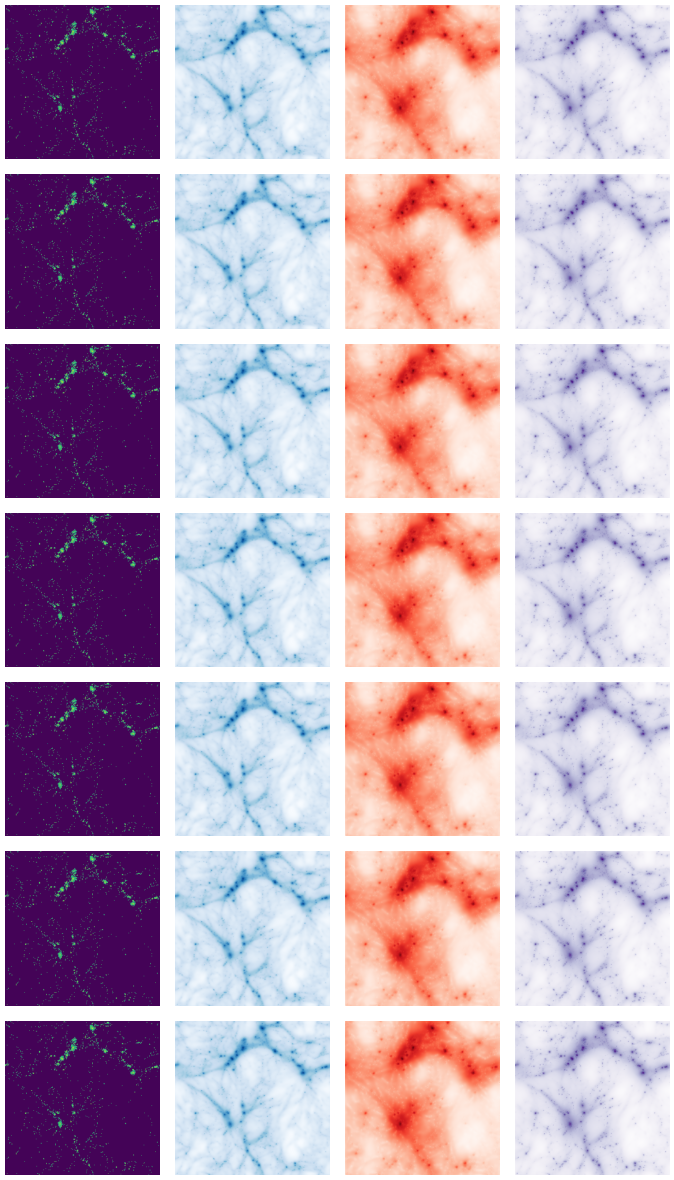

In [32]:
decoded_maps = np.asarray(decoded_maps)

plt.figure(figsize=(7,12))
cms = ['viridis','Blues','Reds','Purples']
for i in range(7):
    for j, c in enumerate(cms):
    
        plt.subplot(7,4,i*4+j+1)
        plt.imshow(decoded_maps[i,j,:,:],cmap=c)
        plt.axis('off')

plt.tight_layout()
plt.savefig('temp.png')
plt.show()

In [24]:
import os
import numpy as np
import torch
from tqdm import tqdm

# =========================
# Utils: normalization & prep
# =========================
def log1p_zscore(arr):
    x = np.log1p(arr.astype(np.float32))
    mu, sd = x.mean(), x.std()
    return (x - mu) / (sd + 1e-8), (mu, sd)

def log1p_zscore_with_stats(arr, mu=None, sd=None):
    x = np.log1p(arr.astype(np.float32))
    if mu is None or sd is None:
        mu, sd = x.mean(), x.std()
    return (x - mu) / (sd + 1e-8), (mu, sd)

def normalize_map(m):
    x = np.log1p(m.astype(np.float32))
    return (x - x.mean()) / (x.std() + 1e-8)

def prepare_resnet_input(star_map, gas_map, T_map, P_map):
    return np.stack([
        normalize_map(star_map),
        normalize_map(gas_map),
        normalize_map(T_map),
        normalize_map(P_map)
    ], axis=0)  # (4, H, W)

# =========================
# Interpolation helpers
# =========================
def lerp(a, b, t):
    return (1 - t) * a + t * b

def slerp(a, b, t, eps=1e-8):
    # Spherical interpolation on vectors
    a = a / (np.linalg.norm(a) + eps)
    b = b / (np.linalg.norm(b) + eps)
    dot = np.clip(np.dot(a, b), -1.0, 1.0)
    omega = np.arccos(dot)
    if omega < 1e-6:
        return lerp(a, b, t)  # nearly identical; fall back to linear
    sin_omega = np.sin(omega)
    return (np.sin((1 - t) * omega) / sin_omega) * a + (np.sin(t * omega) / sin_omega) * b

def interpolate_embeddings(emb1, emb2, num_points=7, mode="slerp"):
    ts = np.linspace(0, 1, num_points, dtype=np.float32)
    if mode == "slerp":
        return np.stack([slerp(emb1, emb2, float(t)) for t in ts], axis=0)
    else:
        return np.stack([lerp(emb1, emb2, float(t)) for t in ts], axis=0)

# =========================
# Model wrapper
# =========================
class ResNetEmbeddingExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=self.device)
        self.model.to(self.device).eval()

    def extract_embeddings(self, input_maps, batch_size=32):
        """
        input_maps: (N, 4, H, W) float32
        returns: (N, D)
        """
        embs = []
        for i in tqdm(range(0, len(input_maps), batch_size), desc="Extracting embeddings"):
            batch = torch.tensor(input_maps[i:i+batch_size], dtype=torch.float32, device=self.device)
            with torch.no_grad():
                z = self.model.resnet_branch(batch)
            embs.append(z.detach().cpu().numpy())
            del batch
            torch.cuda.empty_cache()
        return np.vstack(embs)

    def sample_from_embedding(self, embedding, cdm_mass_map_cond, astro_params, num_steps=200, method='euler'):
        """
        Decode maps from a given embedding vector and conditioning inputs.
        cdm_mass_map_cond: (H, W) float32 (already normalized/noised as desired)
        astro_params: (P,) float32
        returns: (4, H, W) float32
        """
        cdm = torch.tensor(cdm_mass_map_cond, dtype=torch.float32, device=self.device).unsqueeze(0).unsqueeze(0)
        ap  = torch.tensor(astro_params, dtype=torch.float32, device=self.device).unsqueeze(0)
        z   = torch.tensor(embedding, dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            pred = self.model.sample(
                cdm_mass=cdm,
                astro_params=ap,
                cdm_mass_condition=cdm,  # same cond; change if you use a different conditioning tensor
                resnet_input=None,
                resnet_embed=z,
                num_steps=num_steps,
                method=method
            ).cpu().numpy()[0]
        return pred

# =========================
# Dataset assembly across simulations
# =========================
def load_simulation_block(base_dir, sim_name, tag="LH", z_str="0.00"):
    root = os.path.join(base_dir, sim_name)
    star = np.load(os.path.join(root, f"Maps_Mstar_{sim_name}_{tag}_z={z_str}.npy"))
    gas  = np.load(os.path.join(root, f"Maps_Mgas_{sim_name}_{tag}_z={z_str}.npy"))
    T    = np.load(os.path.join(root, f"Maps_T_{sim_name}_{tag}_z={z_str}.npy"))
    P    = np.load(os.path.join(root, f"Maps_P_{sim_name}_{tag}_z={z_str}.npy"))
    cdm  = np.load(os.path.join(root, f"Maps_Mcdm_{sim_name}_{tag}_z={z_str}.npy"))
    # Load astro/cosmo params; adjust file name if yours differs
    params_path = os.path.join(root, f"params_{tag}_{sim_name}.txt")
    params = np.loadtxt(params_path)
    return star, gas, T, P, cdm, params

def build_multi_sim_dataset(simulation_names, base_dir, tag="LH", z_str="0.00",
                            N_per_sim=100, use_random=False, seed=42):
    rng = np.random.default_rng(seed)
    all_inputs = []
    all_cdm_norm = []
    all_astro = []
    all_labels = []
    index_map = []  # list of (sim_name, local_idx) per row appended

    for sim in simulation_names:
        print(f"\nLoading {sim} ...")
        star, gas, T, P, cdm, params = load_simulation_block(base_dir, sim, tag=tag, z_str=z_str)

        N_avail = star.shape[0]
        idxs = np.arange(N_avail)
        if use_random and N_avail > N_per_sim:
            idxs = rng.choice(N_avail, size=N_per_sim, replace=False)
        else:
            idxs = idxs[:min(N_per_sim, N_avail)]

        # Dataset-level normalization for CDM (per sim)
        cdm_norm, (mu_cdm, sd_cdm) = log1p_zscore(cdm)

        # Build inputs
        for i in idxs:
            x4 = prepare_resnet_input(star[i], gas[i], T[i], P[i])  # (4,H,W)
            all_inputs.append(x4.astype(np.float32))
            all_cdm_norm.append(cdm_norm[i].astype(np.float32))
            # many files contain more columns; use first 2 like your original snippet
            all_astro.append(params[i//15, :2].astype(np.float32))
            all_labels.append(sim)
            index_map.append((sim, int(i)))

    all_inputs    = np.stack(all_inputs, axis=0)         # (N_total,4,H,W)
    all_cdm_norm  = np.stack(all_cdm_norm, axis=0)       # (N_total,H,W)
    all_astro     = np.stack(all_astro, axis=0)          # (N_total,2)
    all_labels    = np.array(all_labels)
    index_map     = np.array(index_map, dtype=object)    # (N_total,2) of (sim, local_idx)

    print("\nBuilt dataset:")
    print(" inputs:", all_inputs.shape,
          " cdm:", all_cdm_norm.shape,
          " astro:", all_astro.shape,
          " labels:", all_labels.shape)
    return all_inputs, all_cdm_norm, all_astro, all_labels, index_map

# =========================
# Decode an interpolation path
# =========================
def decode_interpolation_path(extractor, embeddings, idx_a, idx_b,
                              cdm_maps_norm, astro_params,
                              num_points=7, num_steps=200, mode="slerp",
                              condition_source="A", add_noise_sigma=0.0):
    """
    embeddings: (N,D)
    cdm_maps_norm: (N,H,W)
    astro_params: (N,P)
    condition_source: "A", "B", or "avg" (uses A by default)
    add_noise_sigma: std of optional Gaussian noise added to conditioning CDM
    returns:
        interp_Z: (num_points, D)
        decoded:  (num_points, 4, H, W)
    """
    embA = embeddings[idx_a]
    embB = embeddings[idx_b]
    interp_Z = interpolate_embeddings(embA, embB, num_points=num_points, mode=mode)

    if condition_source == "A":
        cond_cdm = cdm_maps_norm[idx_a].copy()
        cond_ap  = astro_params[idx_a].copy()
    elif condition_source == "B":
        cond_cdm = cdm_maps_norm[idx_b].copy()
        cond_ap  = astro_params[idx_b].copy()
    else:  # "avg"
        cond_cdm = 0.5 * (cdm_maps_norm[idx_a] + cdm_maps_norm[idx_b])
        cond_ap  = 0.5 * (astro_params[idx_a] + astro_params[idx_b])

    if add_noise_sigma > 0:
        cond_cdm = cond_cdm + np.random.normal(0.0, add_noise_sigma, size=cond_cdm.shape).astype(np.float32)

    decoded = []
    for z in tqdm(interp_Z, desc="Decoding interpolation"):
        pred = extractor.sample_from_embedding(
            embedding=z,
            cdm_mass_map_cond=cond_cdm,
            astro_params=cond_ap,
            num_steps=num_steps,
            method='euler'
        )
        decoded.append(pred.astype(np.float32))
    decoded = np.stack(decoded, axis=0)  # (num_points,4,H,W)
    return interp_Z, decoded


# ---- Config ----
simulation_names = ["Astrid", "EAGLE", "IllustrisTNG", "SIMBA", "Magneticum"]
base_dir = "/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"
tag = "LH"      # change to "CV" if needed per dataset
z_str = "0.00"
N_per_sim = 100
checkpoint_path = "lightning_logs/new/checkpoints/best-model-epoch=92-val_loss=0.035356.ckpt"

# ---- Build dataset across sims ----
inputs_4ch, cdm_norm, astro_all, labels, index_map = build_multi_sim_dataset(
    simulation_names, base_dir, tag=tag, z_str=z_str, N_per_sim=N_per_sim, use_random=False
)

# ---- Extract embeddings ----
extractor = ResNetEmbeddingExtractor(checkpoint_path)
embeddings = extractor.extract_embeddings(inputs_4ch, batch_size=32)

# ---- Save embeddings + labels for later t-SNE/UMAP ----
np.save("resnet_embeddings.npy", embeddings)
np.save("resnet_labels.npy", labels)
np.save("resnet_index_map.npy", index_map)  # (sim_name, local_idx) per row
print("\nSaved: resnet_embeddings.npy, resnet_labels.npy, resnet_index_map.npy")

# ---- Choose two absolute indices for interpolation (edit these) ----
abs_idx_A = 0
abs_idx_B = 5

# ---- Decode interpolation path (uses A's conditioning by default) ----
interp_Z, decoded_maps = decode_interpolation_path(
    extractor,
    embeddings,
    idx_a=abs_idx_A,
    idx_b=abs_idx_B,
    cdm_maps_norm=cdm_norm,
    astro_params=astro_all,
    num_points=7,
    num_steps=200,
    mode="slerp",            # or "linear"
    condition_source="A",    # "A", "B", or "avg"
    add_noise_sigma=0.0
)

# ---- Save interpolation outputs ----
# np.save("interp_embeddings.npy", interp_Z)          # (num_points, D)
# np.save("interp_decoded_maps.npy", decoded_maps)    # (num_points, 4, H, W)
# print("Saved: interp_embeddings.npy, interp_decoded_maps.npy")

# Convenience printouts
print(f"\nChosen pair:")
print(f"A = {index_map[abs_idx_A]} @ abs_idx {abs_idx_A}")
print(f"B = {index_map[abs_idx_B]} @ abs_idx {abs_idx_B}")
print("Decoded maps shape (num_points, 4, H, W):", decoded_maps.shape)



Loading Astrid ...

Loading EAGLE ...

Loading IllustrisTNG ...

Loading SIMBA ...

Loading Magneticum ...

Built dataset:
 inputs: (500, 4, 256, 256)  cdm: (500, 256, 256)  astro: (500, 2)  labels: (500,)


Extracting embeddings: 100%|████████████████████| 16/16 [00:00<00:00, 43.28it/s]



Saved: resnet_embeddings.npy, resnet_labels.npy, resnet_index_map.npy


Decoding interpolation: 100%|█████████████████████| 7/7 [00:05<00:00,  1.26it/s]


Chosen pair:
A = ['Astrid' 0] @ abs_idx 0
B = ['Astrid' 5] @ abs_idx 5
Decoded maps shape (num_points, 4, H, W): (7, 4, 256, 256)


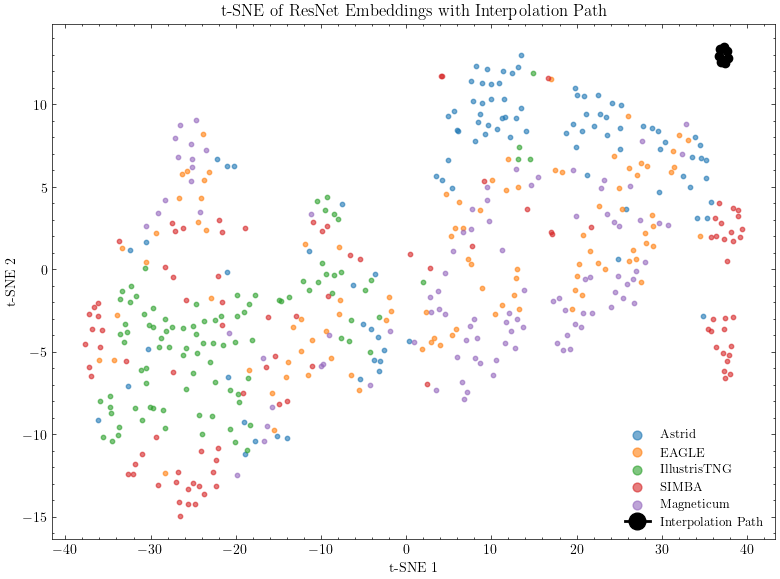

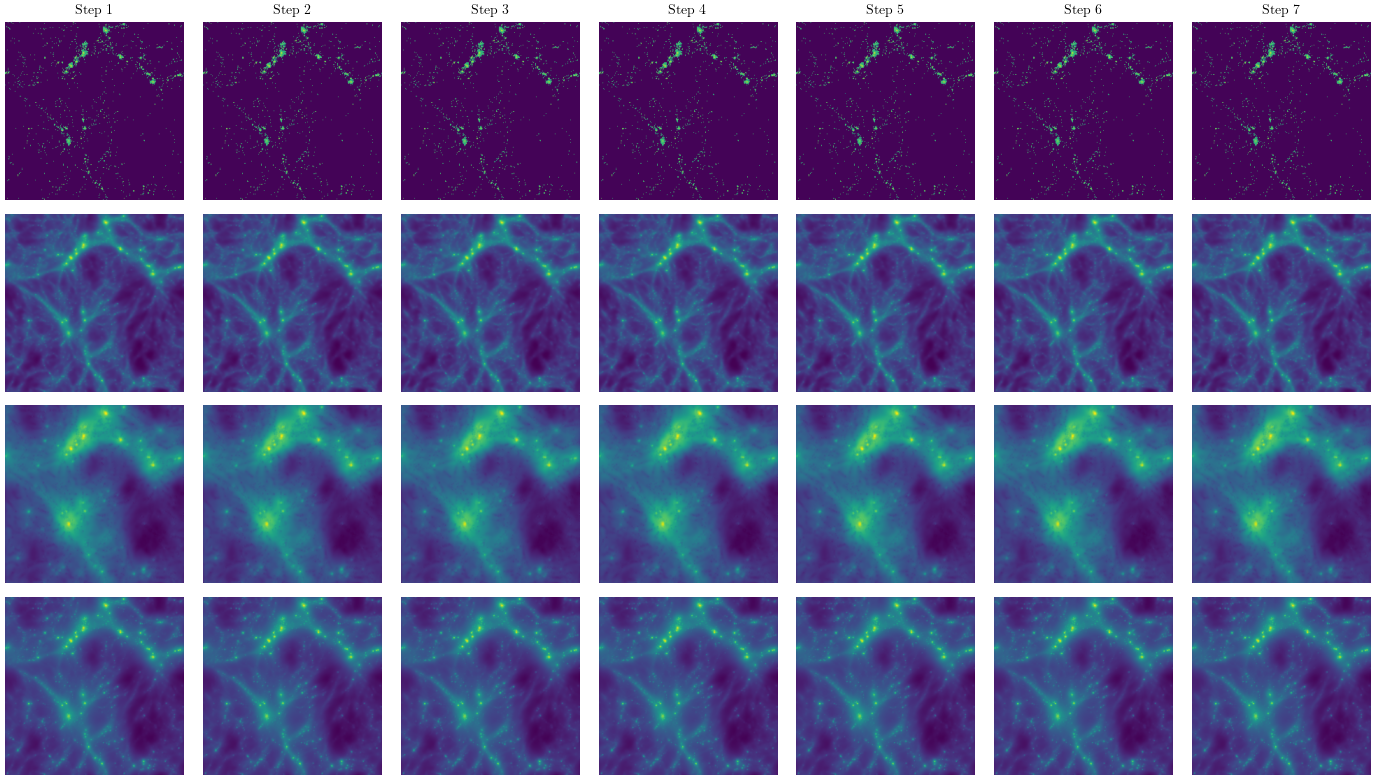

In [25]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.manifold import TSNE
import scienceplots
plt.style.use('science')

def plot_tsne_with_path(embeddings, labels, interp_Z, sim_names, save_path=None):
    """
    embeddings: (N,D)
    labels: (N,)
    interp_Z: (num_points,D) interpolated embeddings
    sim_names: list of unique sim names in the same order as labels values
    """
    # Fit t-SNE on combined embeddings
    combined = np.vstack([embeddings, interp_Z])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
    tsne_all = tsne.fit_transform(combined)
    
    tsne_emb = tsne_all[:len(embeddings)]
    tsne_interp = tsne_all[len(embeddings):]
    
    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("tab10", len(sim_names))
    color_map = {sim: palette[i] for i, sim in enumerate(sim_names)}
    
    # Scatter embeddings
    for sim in sim_names:
        mask = (labels == sim)
        plt.scatter(tsne_emb[mask, 0], tsne_emb[mask, 1], 
                    label=sim, s=10, alpha=0.6, color=color_map[sim])
    
    # Plot interpolation path
    plt.plot(tsne_interp[:, 0], tsne_interp[:, 1], '-o', color='black', lw=2, ms=6, label='Interpolation Path')
    
    plt.legend(markerscale=2, fontsize=9)
    plt.title("t-SNE of ResNet Embeddings with Interpolation Path")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

# =========================
# Grid of interpolated reconstructions
# =========================
def plot_interp_reconstructions(decoded_maps, save_path=None):
    """
    decoded_maps: (num_points, 4, H, W) in order (stars, gas, temp, pressure)
    """
    num_points = decoded_maps.shape[0]
    map_names = ["Stars", "Gas", "Temperature", "Pressure"]
    
    fig, axes = plt.subplots(4, num_points, figsize=(2*num_points, 8))
    
    for r in range(4):
        for c in range(num_points):
            ax = axes[r, c] if num_points > 1 else axes[r]
            im = ax.imshow(decoded_maps[c, r], cmap='viridis')
            ax.axis('off')
            if r == 0:
                ax.set_title(f"Step {c+1}", fontsize=10)
        axes[r, 0].set_ylabel(map_names[r], fontsize=10)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()


sim_names_unique = list(dict.fromkeys(labels))  # preserve order

# Plot t-SNE
plot_tsne_with_path(embeddings, labels, interp_Z, sim_names_unique, save_path="tsne_interp.png")

# Plot reconstruction grid
plot_interp_reconstructions(decoded_maps, save_path="interp_recon_grid.png")
